# <h3 style="text-align: center;"> <strong> UNIVERSIDAD TECNOLÓGICA DE PANAMÁ </strong></h3>
<h3 style="text-align: center;">FACULTAD DE INGENIERÍA DE SISTEMAS COMPUTACIONALES</h3>
<h3 style="text-align: center;">DEPARTAMENTO DE COMPUTACIÓN Y SIMULACIÓN DE SISTEMAS</h3>
    
<h1 style="text-align: center;"><strong>-------LABORATORIO N°6:  Aprendizaje Supervisado-------</strong></h1>
<h3 style="text-align: center;">ANÁLISIS DE DATOS </h3>




|  **FACILITADOR** | Dr. José Carlos Rangel Ortiz          |
|-----------------|---------------------------------------|
| **MÓDULO 2**    | Metodos de Inteligencia Computacional y su aplicación en Ciencia de Datos    |
|  **UNIDAD 3**    | Tipos de Aprendizaje      |
    

| **NOMBRE DE LOS ESTUDIANTES:** | Rebeca Mendoza|
|----------------------------|-----------------------------------------------------------------------------------------|

# Introudcción 


El Aprendizaje Automático(ML) y la Ciencia de Datos se entrelazan como dos piezas de un rompecabezas, formando una poderosa herramienta para la extracción de conocimiento a partir de datos. El ML enriquece el campo de la Ciencia de Datos, impulsando el análisis y la toma de decisiones informadas.

El ML dota a los científicos de datos de algoritmos inteligentes que pueden aprender de grandes conjuntos de datos sin necesidad de una programación explícita. Estos algoritmos son capaces de identificar patrones complejos, realizar predicciones y tomar decisiones autónomas, lo que permite a los científicos de datos:

- Automatizar tareas tediosas
- Descubrir patrones ocultos
- Realizar predicciones precisas
- Realizar predicciones precisas

**Casos de uso del Aprendizaje Automático en la Ciencia de Datos**

- Análisis de fraude
- Recomendación de productos
- Detección de anomalías
- Segmentación de clientes
- Reconocimiento de imágenes


En este laboratorio se daran los primeros pasos con algoritmos de ML, en este caso Aprendizaje Supervisado el cual se enfoca en el entrenamiento de modelos utilizando una variable como guía del entrenamiento. Nos enfocaremos en primer lugar con los algoritmos de Regresión Lineal, Regresión Logística y Árboles de Decisión. Se presentan para cada uno ejemplos desarrollados donde se expone su uso y forma de análisis de los mismos. 

La Ciencia de Datos proporciona el marco y la metodología para recopilar, limpiar, preparar y analizar datos, mientras que el ML ofrece las herramientas y algoritmos para aprender de estos datos y extraer conocimiento. Juntos, forman un dúo dinámico que permite a las organizaciones transformar sus datos en activos valiosos que pueden impulsar la innovación, la eficiencia y la toma de decisiones estratégicas.



<div class="alert alert-success", role="alert">
    <h1 style="font-size: 1.5em;">Parte 1 </h1>
    <h2 style="font-size: 1.5em; "><strong>Regresión Lineal Simple</strong></h2>
</div>


La regresión lineal simple es un tipo de algoritmo de aprendizaje supervisado que permite generar un modelo de predicción para un *target* o varible objetivo discreta. 
El enfoque simple de este algoritmo se recibe una conjunto de datos de entrada con una sola columa o variable y permite realizar la predicción de una variable. Este algoritmo al igual que todos lo algoritmos supervisados requiere de un conjunto de datos con el valor real dentro del conjunto de entrenamiento. 
En este caso se utilizara el *LinearRegression* de la librería de SciKitLearn para predecir valores numéricos. 
El enfoque de Regresión Lineal Simple genera una recta que representa los valores del conjunto de entrenamiento.
La ecuación que la representa sería:

$y=mX + b$

Siendo $m$ la pendiente de la recta que en este caso consiste en un solo valor al utilizar solo una variable de entrada. Cuando se utilicen más valores, $m$ se interpreta como un arreglo o lista de coeficientes que multiplican a cada variable utilizada en el entrenamiento.
El algoritmo de Regresión Lineal de SciKitLearn calcula estos parámetros que representan los datos de entrenamiento. 


## Importar Librerias

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt 
import matplotlib.pyplot as plt
import palmerpenguins
import pandas as pd
import sklearn.metrics

## Cargar el dataset del promedio de las altas temperaturas
En este caso se plantea un modelo que permita el calculo de la temperatura **(variable *y*)**, recibiendo como entrada el año **(variable *x*)**, de tal manera que se obtiene una ecuación con la siguiente estructura:

$temperatura = m(anio) + intercepto$

In [2]:
nyc = pd.read_csv('ave_hi_nyc_jan_1895-2018.csv')
nyc.columns = ['Date', 'Temperature', 'Anomaly']
nyc.Date = nyc.Date.floordiv(100)
nyc.head(3)

,Date,Temperature,Anomaly
0,1895,34.2,-3.2
1,1896,34.7,-2.7
2,1897,35.5,-1.9


## División en Train/Test 
Cuando se realiza un entrenamiento de un modelo de ML es recomendable dividir el dataset en dos secuencias, una para entrenar y otra para evaluar el modelo entrenado. La función *train_test_split* nos permite realizar esta divisióon de nuestros conjuntos de datos. 
En este ejemplo como en la mayoria de los códigos de entrenamiento, se utiliza un conjunto de valores para entrenar el modelo, se suele llamar **X** al conjunto de valores o la variable que se usa para entrenar el modelo y se suele llamar **Y** a la columna o variable objetivo de nuestro dataset y la cual el modelo debe aprender a predecir. En este caso al no especificar porcentaje se utiliza por defecto el 25% para test y el 75% para train.

Esta función por lo tanto recibe basicamente 2 elementos, el dataset con la variable **X** y el dataset con la varible **Y**. La funcion devuelve 4 listas a saber:
- **X_train** : son las instancias seleccionadas de la variable X que se usaran para **entrenar** el modelo.
- **X_test**: son las instancias seleccionadas de la variable X que se usaran para **evaluar** el modelo.
- **y_train**: son las categorias o valores reales de las instancias contenidas en la lista **X_train**.
- **y_test**: son las categorias o valores reales de las instancias contenidas en la lista **X_test**.

El entrenamiento en este caso utilizará los valores con el sufijo \_train para entrenar y los que tienen el sufijo \_test para validar el modelo entrenado.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(nyc.Date.values.reshape(-1, 1), nyc.Temperature.values, random_state=11)

# En este caso el .values retorna una lista de flotantes  [123,3,...,5] --> [[123], [3], ... , [5]]
# y el .reshape(-1,1) especifica que esa lista se transforme a un arreglo de una columna
# debido a que es el formato que maneja SKLeanr

In [4]:
print(f'El conjunto original tenia {len(nyc)} instancias, el conjunto de train tiene {len(X_train)} y el conjunto de test {len(X_test)} instancias.')

El conjunto original tenia 124 instancias, el conjunto de train tiene 93 y el conjunto de test 31 instancias.


## Entrenamiento del Modelo
Para el proceso de entrenar el modelo primero se crea una instancia del modelo a utilizar y posteriormente se usa el metodo **.fit()** para que se envie el conjunto de entrenamiento y se realice el entrenamiento del modelo. Cada algoritmo tiene un conjunto de parámetros que puede recibir y que permiten ajustar o mejorar el resultado.

In [5]:
linear_regression = LinearRegression()
linear_regression.fit(X=X_train, y=y_train)

LinearRegression()

In [6]:
print(f'El coeficiente de la ecuación es {linear_regression.coef_[0]:0.4f} y la intercepción con el eje es en el punto {linear_regression.intercept_:0.4f}.')
print(f'Ecuación resultante: y={linear_regression.coef_[0]:0.4f}X + {linear_regression.intercept_:0.4f}') 

El coeficiente de la ecuación es 0.0194 y la intercepción con el eje es en el punto -0.3078.
Ecuación resultante: y=0.0194X + -0.3078


## Evaluación del Modelo
Para evaluar el modelo se envía mediante la funcion **predict()** el conjunto de test o evaluación al modelo, esto realiza las predicciones para los valores recibidos.
De igual manera usando la funcion **score()** la cual recibe el conjunto de test y el valor real del conjunto de test, se puede obtener la métrica de evaluación del modelo, este se interpreta como un valor de $R^2$. 

# Cálculo del error/score del modelo mediante el coeficiente de determinación $R^2$

El R-cuadrado es una medida estadística de qué tan cerca están los datos de la línea de regresión ajustada. También se conoce como coeficiente de determinación, o coeficiente de determinación múltiple si se trata de regresión múltiple.

La definición de $R^2$ es bastante sencilla: es el porcentaje de la variación en la variable de respuesta que es explicado por un modelo lineal. 

 $$R^2(y,\hat{y}) =1 - \frac{\sum_{i=1}^{n}(y_i-\hat{y_i})^2}{\sum_{i=1}^{n}(y_i-\bar{y})^2}$$

 Donde
 $$y_i=Valor Verdadero$$
$$\hat{y_i}=Predicción$$ 
$$\bar{y} = \frac{1}{n}\sum_{i=1}^{n}y_i$$
$$\sum_{i=1}^{n}(y_i-\hat{y_i})^2 = \sum_{i=1}^{n}\epsilon_i^2$$

In [7]:
# realizar la prediccion
predicted = linear_regression.predict(X_test)
expected = y_test

# Imprimir cada 5 valores de la predicción 
for p, e in zip(predicted[::5], expected[::5]):
     print(f'predicted: {p:.2f}, expected: {e:.2f}')
        
print(f'El score obtenido por el modelo es {linear_regression.score(X_test, y_test)}')

predicted: 37.86, expected: 31.70
predicted: 38.69, expected: 34.80
predicted: 37.00, expected: 39.40
predicted: 37.25, expected: 45.70
predicted: 38.05, expected: 32.30
predicted: 37.64, expected: 33.80
predicted: 36.94, expected: 39.70
El score obtenido por el modelo es -0.033370346388810646


## Predicción de Temperaturas Futuras y Pasadas

In [8]:
# Función lambda para predicción de valores mediante la construcción de la ecuación
predictor = (lambda x: linear_regression.coef_ * x + linear_regression.intercept_)

In [9]:
# Predicción usando el método predict
# El método espera un vector de vectores, 
# por eso para un valor simple se debe 
# usar una notación de doble [[]]
print(f'La predicion para el anio 2019 usando el modelo  es {linear_regression.predict([[2019]])}.')

La predicion para el anio 2019 usando el modelo  es [38.84399018].


In [10]:
# Predicción usando ecuación
print(f'La predición para el anio 2019 usando la función lambda  es {predictor(2019)}.')

La predición para el anio 2019 usando la función lambda  es [38.84399018].


## Visualizar el dataset con la línea de regresión
Se puede graficar el resultado para comparar con la información del dataset.

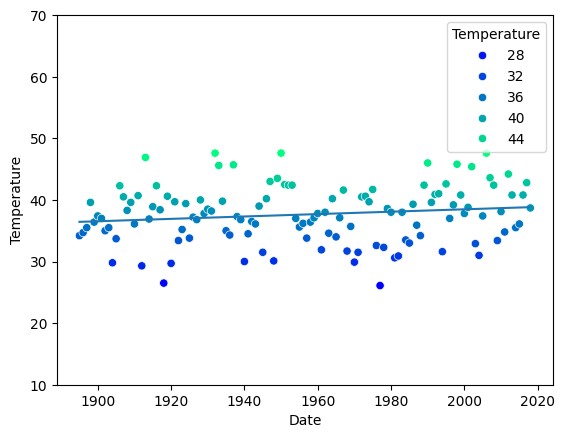

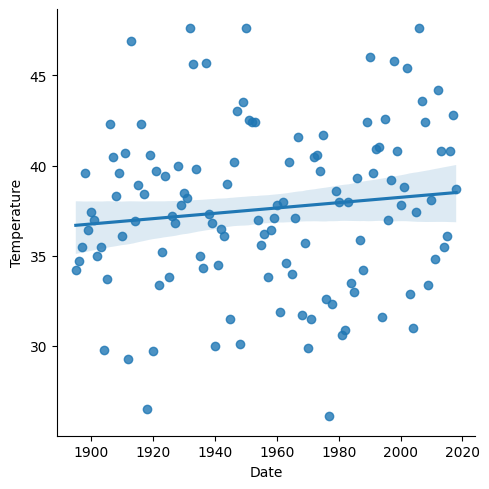

In [11]:
axes = sns.scatterplot(data=nyc, x='Date', y='Temperature',hue='Temperature', palette='winter', legend=True)
axes.set_ylim(10, 70)

x = np.array([min(nyc.Date.values), max(nyc.Date.values)])
y = predictor(x)

line = plt.plot(x, y)

# Usando un sns.lmplot
sns.lmplot(data=nyc, x='Date', y='Temperature')

<div class="alert alert-info", role="success">
    <h1 style="font-size: 2em;">Modelos con Regresión Lineal Múltiple </h1>
    <h1 style="font-size: 2em;">Entrene de un modelo de predicción del peso de un pinguino usando solo las variables numéricas, tampoco utilice el año del dataset. </h1>
</div>

En este caso utilizará el enfoque múltiple en el cual el conjunto X contiene más de una variable para realizar el entrenamiento y predicción, por lo  cual, en este casos el conjunto **X** es una matriz y el conjunto **Y** un vector o lista de una dimensión. 

## **[1]** Cargue el dataset y elimine los NaNs de ser necesario

In [12]:
# Carga el dataset palmerpenguins
penguins_df= palmerpenguins.load_penguins()
penguins_df.head()

# Elimina las filas con valor NaNs
penguins_df = penguins_df.dropna()

# Muestra las 5 primeras filas del dataset
display(penguins_df.head())

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007


## **[2]** Genere el dataset solo con las variables numéricas (función **.drop()**)

In [13]:
# Elimina las columnas no numéricas incluyendo a la variable año
penguins_df_numerico = penguins_df.select_dtypes(include='number').drop(columns=['year'], errors='ignore')

# Mostrar las 5 primeras filas
print(penguins_df_numerico.head())

   bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
0            39.1           18.7              181.0       3750.0
1            39.5           17.4              186.0       3800.0
2            40.3           18.0              195.0       3250.0
4            36.7           19.3              193.0       3450.0
5            39.3           20.6              190.0       3650.0


## **[3]** Divida el dataset en conjunto de Train y Test

In [14]:
# Separa las variables predictoras (X) y la variable objetivo (y)
x = penguins_df_numerico.drop(columns=['body_mass_g'])  # Variables predictoras
y = penguins_df_numerico['body_mass_g'] # Variable a predecir

# Divide el dataset en entrenamiento y prueba
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=42
)

print(f'El conjunto original tenia {len(penguins_df)} instancias, el conjunto de train tiene {len(x_train)} y el conjunto de test {len(x_test)} instancias.')

El conjunto original tenia 333 instancias, el conjunto de train tiene 249 y el conjunto de test 84 instancias.


## **[4]** Entrene el modelo de predicción mediante Regresión Lineal

In [15]:
# Crear y entrenar el modelo
modelo = LinearRegression()
modelo.fit(x_train, y_train)

print(f'El coeficiente de la ecuación es {modelo.coef_[0]:0.4f} y la intercepción con el eje es en el punto {modelo.intercept_:0.4f}.')
print(f'Ecuación resultante: y={modelo.coef_[0]:0.4f}X + {modelo.intercept_:0.4f}') 

El coeficiente de la ecuación es 8.3762 y la intercepción con el eje es en el punto -6563.0953.
Ecuación resultante: y=8.3762X + -6563.0953


## **[5]** Calcule el *score* de su modelo

In [16]:
# Predicciones
predicted = modelo.predict(x_test)
expected = y_test

# Imprime cada 5 valores de la predicción
for p, e in zip(predicted[::5], expected[::5]):
    print(f'predicted: {p:.2f}, expected: {e:.2f}')
    
print(f'El score obtenido por el modelo es {modelo.score(x_test, y_test)}')

predicted: 3012.46, expected: 3250.00
predicted: 4374.12, expected: 4300.00
predicted: 3957.92, expected: 4700.00
predicted: 3335.66, expected: 3400.00
predicted: 3972.11, expected: 4075.00
predicted: 3509.83, expected: 2900.00
predicted: 4764.64, expected: 4400.00
predicted: 3913.76, expected: 3800.00
predicted: 3204.87, expected: 3300.00
predicted: 3419.52, expected: 3550.00
predicted: 3699.30, expected: 3725.00
predicted: 4903.02, expected: 5500.00
predicted: 3485.89, expected: 3350.00
predicted: 3726.16, expected: 3400.00
predicted: 3586.86, expected: 3800.00
predicted: 4454.05, expected: 5050.00
predicted: 2925.49, expected: 3450.00
El score obtenido por el modelo es 0.7431967862149031


## Convertir a variable numérica el género, la isla y la especie y entrenar nuevamente.
Utilice el enfoque de LabelEncoding para convertir las columnas categóricas originales (especie, isla y sexo) a numéricas y entrene un nuevo modelo.
Puede consultar la siguiente pagina : https://www.turing.com/kb/convert-categorical-data-in-pandas-and-scikit-learn#label-encoding 

## **[6]** Genere el las secuencias X & Y para entrenar el modelo

In [24]:
# Separar variables predictoras (X) y la variable objetivo (y)
x = penguins_df.drop(columns=['body_mass_g', 'year'])  # Ajusta según tu dataset
y = penguins_df['body_mass_g']

## **[7]** Aplique el LabelEncoder

In [23]:
# ESTO SE HACE PRIMERO PARA QUE FUNCIONE
from sklearn.preprocessing import LabelEncoder

# Convertir columnas categóricas a númericas 
cols_categoricas = ['species', 'island', 'sex']
for col in cols_categoricas:
    if col in penguins_df.columns:
        le = LabelEncoder()
        penguins_df[col] = le.fit_transform(penguins_df[col])
        
print(x_train.dtypes)

species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
sex                   object
dtype: object


## **[8]** Divida el dataset en conjunto de Train y Test

In [25]:
# Divide el dataset en entrenamiento y prueba
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=42
)

print(f'El conjunto original tenia {len(penguins_df)} instancias, el conjunto de train tiene {len(x_train)} y el conjunto de test {len(x_test)} instancias.')

El conjunto original tenia 333 instancias, el conjunto de train tiene 249 y el conjunto de test 84 instancias.


## **[9]** Entrene el modelo de predicción mediante Regresión Lineal

In [26]:
from sklearn.linear_model import LinearRegression

modelo_rl = LinearRegression()
modelo_rl.fit(x_train, y_train)

print(f'El coeficiente de la ecuación es {modelo_rl.coef_[0]:0.4f} y la intercepción con el eje es en el punto {modelo_rl.intercept_:0.4f}.')
print(f'Ecuación resultante: y={modelo_rl.coef_[0]:0.4f}X + {modelo_rl.intercept_:0.4f}')

El coeficiente de la ecuación es 267.6944 y la intercepción con el eje es en el punto -1584.3588.
Ecuación resultante: y=267.6944X + -1584.3588


## **[10]** Calcule el *score* de su modelo

In [27]:
# Predicciones
predicted = modelo_rl.predict(x_test)
expected = y_test

# Imprime cada 5 valores de la predicción
for p, e in zip(predicted[::5], expected[::5]):
    print(f'predicted: {p:.2f}, expected: {e:.2f}')
    
print(f'El score obtenido por el modelo es {modelo_rl.score(x_test, y_test)}')

predicted: 2994.55, expected: 3250.00
predicted: 4246.44, expected: 4300.00
predicted: 3958.40, expected: 4700.00
predicted: 3259.82, expected: 3400.00
predicted: 4153.66, expected: 4075.00
predicted: 3219.79, expected: 2900.00
predicted: 4626.60, expected: 4400.00
predicted: 4075.79, expected: 3800.00
predicted: 3091.84, expected: 3300.00
predicted: 3241.17, expected: 3550.00
predicted: 3597.73, expected: 3725.00
predicted: 5236.47, expected: 5500.00
predicted: 3490.89, expected: 3350.00
predicted: 3437.02, expected: 3400.00
predicted: 3473.05, expected: 3800.00
predicted: 4463.60, expected: 5050.00
predicted: 2816.30, expected: 3450.00
El score obtenido por el modelo es 0.8110732531490119


<div class="alert alert-info", role="success">
    <h1 style="font-size: 2em;">Utilizando el dataset Diamonds, entrene un modelo para la prediccion del precio del diamante usando solo las variables numericas. </h1>
</div>


## **[11]** Cargue el dataset y elimine los NaNs si el dataset cuenta con alguno.

In [28]:
# Cargar dataset diamonds
diamonds_df = sns.load_dataset('diamonds')

# Mostrar las 5 primeras filas del dataset
diamonds_df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


## **[12]** Seleccione solo las columnas numéricas y genere su conjunto X, Y

In [29]:
# Elimina las columnas no numéricas incluyendo a la variable año
diamonds_df_numerico = diamonds_df.select_dtypes(include='number')

# Mostrar las 5 primeras filas
print(diamonds_df_numerico.head())

# Separa las variables predictoras (X) y la variable objetivo (y)
x = diamonds_df_numerico.drop(columns=['price'])  # Variables predictoras
y = diamonds_df_numerico['price'] # Variable a predecir

   carat  depth  table  price     x     y     z
0   0.23   61.5   55.0    326  3.95  3.98  2.43
1   0.21   59.8   61.0    326  3.89  3.84  2.31
2   0.23   56.9   65.0    327  4.05  4.07  2.31
3   0.29   62.4   58.0    334  4.20  4.23  2.63
4   0.31   63.3   58.0    335  4.34  4.35  2.75


## **[13]** Divida el dataset en conjunto de Train y Test

In [30]:
# Divide el dataset en entrenamiento y prueba
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=42
)

print(f'El conjunto original tenia {len(diamonds_df)} instancias, el conjunto de train tiene {len(x_train)} y el conjunto de test {len(x_test)} instancias.')

El conjunto original tenia 9263 instancias, el conjunto de train tiene 6947 y el conjunto de test 2316 instancias.


## **[14]** Entrene el modelo de predicción mediante Regresión Lineal

In [31]:
# Crear y entrenar el modelo
modelo_diamonds = LinearRegression()
modelo_diamonds.fit(x_train, y_train)

print(f'El coeficiente de la ecuación es {modelo_diamonds.coef_[0]:0.4f} y la intercepción con el eje es en el punto {modelo_diamonds.intercept_:0.4f}.')
print(f'Ecuación resultante: y={modelo_diamonds.coef_[0]:0.4f}X + {modelo_diamonds.intercept_:0.4f}') 

El coeficiente de la ecuación es -3897.0636 y la intercepción con el eje es en el punto -17656.6636.
Ecuación resultante: y=-3897.0636X + -17656.6636


## **[15]** Calcule el *score* de su modelo

In [32]:
# Predicciones
predicted = modelo_diamonds.predict(x_test)
expected = y_test

# Imprime cada 5 valores de la predicción
for p, e in zip(predicted[::5], expected[::5]):
    print(f'predicted: {p:.2f}, expected: {e:.2f}')
    
print(f'El score obtenido por el modelo es {modelo_diamonds.score(x_test, y_test)}')

predicted: 4002.01, expected: 4434.00
predicted: 3406.44, expected: 2933.00
predicted: 1290.45, expected: 562.00
predicted: 3562.38, expected: 3307.00
predicted: 4049.33, expected: 4084.00
predicted: 936.18, expected: 571.00
predicted: 3867.09, expected: 3102.00
predicted: 3950.04, expected: 3651.00
predicted: 3225.36, expected: 3576.00
predicted: 4155.55, expected: 4326.00
predicted: 3253.27, expected: 2903.00
predicted: 3020.07, expected: 2910.00
predicted: 3567.47, expected: 3593.00
predicted: 3997.53, expected: 4189.00
predicted: 4069.27, expected: 4425.00
predicted: 3916.96, expected: 3614.00
predicted: 3957.74, expected: 2801.00
predicted: 3098.01, expected: 3122.00
predicted: 675.21, expected: 412.00
predicted: 4348.29, expected: 4113.00
predicted: 3470.40, expected: 2797.00
predicted: 3216.60, expected: 3909.00
predicted: 3290.39, expected: 3266.00
predicted: 4203.12, expected: 4319.00
predicted: 3456.23, expected: 3514.00
predicted: 3822.81, expected: 4478.00
predicted: 3180.6

<div class="alert alert-success", role="alert">
    <h1 style="font-size: 1.5em;">Parte 2 </h1>
    <h2 style="font-size: 1.5em; "><strong>Regresión Logística con SKLearn</strong></h2>
</div>

La Regresión Logística es un caso de la Regresión Lineal, con la única diferencia de que en este caso se utiliza solo para variables discretas o categóricas. Por lo cual, nuestra variable objetivo o **target** es una categoría dentro del dataset y la salida del modelo de predicción se limita a los valores disponibles dentro de la variable que se esta prediciendo.

**basado en: https://www.aprendemachinelearning.com/regresion-logistica-con-python-paso-a-paso/**

In [33]:
import pandas as pd
import numpy as np
from sklearn import linear_model
from sklearn import model_selection
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sb

## Cargamos los datos de entrada del archivo csv
En este caso el dataset tiene 3 categorías de usuarios de sistemas operativos, por lo cual, se creará un modelo de prediccián de que tipo de usuario se trata basado en ciertos atributos de cada tipo de usuario.

In [34]:
dataframe = pd.read_csv(r"usuarios_win_mac_lin.csv")
dataframe.head()

,duracion,paginas,acciones,valor,clase
0,7.0,2,4,8,2
1,21.0,2,6,6,2
2,57.0,2,4,4,2
3,101.0,3,6,12,2
4,109.0,2,6,12,2


In [35]:
dataframe.describe()

,duracion,paginas,acciones,valor,clase
count,170.000000,170.000000,170.000000,170.000000,170.000000
mean,111.075729,2.041176,8.723529,32.676471,0.752941
std,202.453200,1.500911,9.136054,44.751993,0.841327
min,1.000000,1.000000,1.000000,1.000000,0.000000
25%,11.000000,1.000000,3.000000,8.000000,0.000000
50%,13.000000,2.000000,6.000000,20.000000,0.000000
75%,108.000000,2.000000,10.000000,36.000000,2.000000
max,898.000000,9.000000,63.000000,378.000000,2.000000


## Exploramos un poco el dataset

In [36]:
print(dataframe.groupby('clase').size())

clase
0    86
1    40
2    44
dtype: int64


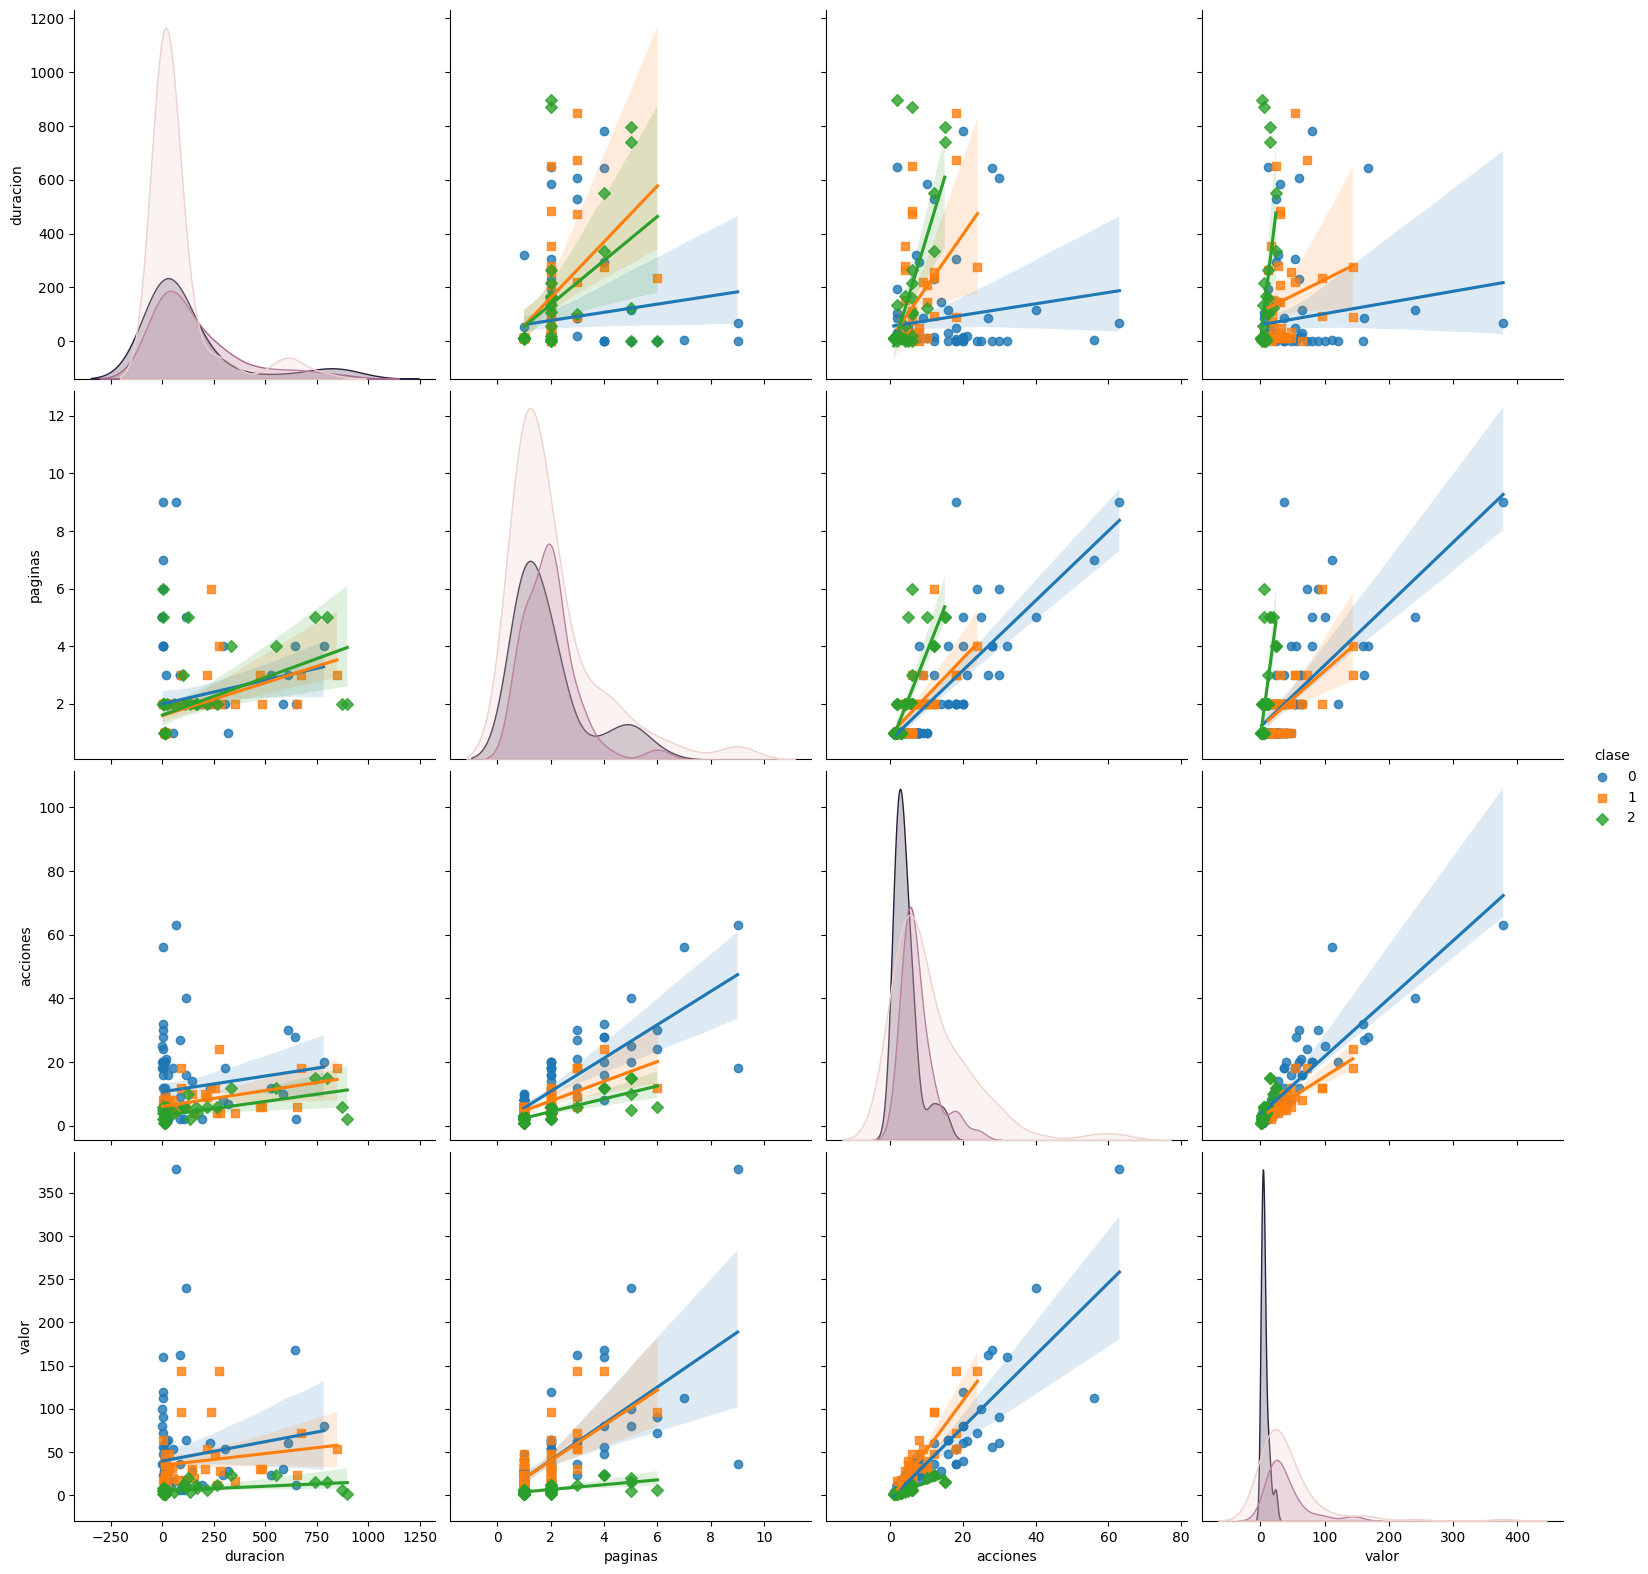

In [37]:
sb.pairplot(dataframe.dropna(), 
            hue='clase',
            height=4,
            vars=["duracion", "paginas","acciones","valor"],
            kind='reg',  
            markers=["o", "s", "D"])

## Creamos el modelo

In [38]:
# Definición de los elementos X & Y
X = np.array(dataframe.drop(['clase'], axis='columns'))
y = np.array(dataframe['clase'])
X.shape

(170, 4)

In [39]:
# Entrenamiento del Modelo
model = linear_model.LogisticRegression(max_iter=500)
model.fit(X,y)

LogisticRegression(max_iter=500)

In [40]:
# Clase que el modelo predijo para cada instancia
predictions = model.predict(X)
print(predictions[::5])

[2 2 2 2 0 1 1 2 0 1 0 0 0 0 0 1 0 0 0 2 0 0 2 2 2 2 0 0 0 2 0 2 0 0]


## En este caso el **score** del modelo se trata de una medida de la exactitud/accuracy del modelo usando sus predicciones sobre el conjunto de datos, esta se entiende como la cantidad de aciertos divida entre la cantidad total de instancias.



In [41]:
print(f'El porcentaje de aciertos del modelo fue {model.score(X,y)}')

El porcentaje de aciertos del modelo fue 0.7764705882352941


## Validación del Modelo
En este caso se realiza una división del dataset en train/test y se usa un enfoque de Cross Validation para evaluar la exactitud de un modelo entrenado usando una secuencia de train y test.

Más Información: https://datascientest.com/en/the-importance-of-cross-validation

In [42]:
validation_size = 0.20
seed = 7
X_train, X_validation, Y_train, Y_validation = model_selection.train_test_split(X, y, test_size=validation_size, random_state=seed)

In [43]:
name='Logistic Regression'
kfold = model_selection.KFold(n_splits=10)
cv_results = model_selection.cross_val_score(model, X_train, Y_train, cv=kfold, scoring='accuracy')
msg = "Clasificador de %s: %f STD: (%f)" % (name, cv_results.mean(), cv_results.std())
print(f'El resultado del modelo evaluado con Cross Validation fue\n:  {msg}')

c:\Users\Rebeca MG\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Rebeca MG\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-lear

El resultado del modelo evaluado con Cross Validation fue
:  Clasificador de Logistic Regression: 0.728571 STD: (0.094186)


## De igual manera se puede calcular el accuracy mediante el método **accuracy_score** de SKLearn, el cual recibe el valor real para cada instancia y la predicción realizada para cada instancia.

In [44]:
predictions = model.predict(X_validation)
print(f'El resultado del modelo evaluado con usando el conjunto de validación es:  {accuracy_score(Y_validation, predictions):.4f}.')

El resultado del modelo evaluado con usando el conjunto de validación es:  0.8529.


## Reporte de Resultados y Matriz de Confusión
### Classification Report
El reporte de resultados que genera SKLearn utiliza las predicciones y el valor real para cada instancia y calcula un conjunto de métricas que permiten entender el comportamiento y los resultados del clasificador.


In [45]:
print(classification_report(Y_validation, predictions))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86        18
           1       1.00      0.50      0.67         6
           2       0.83      1.00      0.91        10

    accuracy                           0.85        34
   macro avg       0.89      0.80      0.81        34
weighted avg       0.87      0.85      0.84        34



### Matriz de Confusión 
La matriz de confusión es un elemento fundamental para el aprendizaje supervisado en la predicción de categorías. Esta permite entender el comportamiento del modelo en comparativa con todas las categorías del dataset. Sus análisis permite identificar donde estan los errores del modelo y entre cuales clases se presenta una mayor confusión. 

Se presentan 2 maneras de calcularla, la primera mediante la función *confusion_matrix* la cual devuelve una cadena con la configuración de la matriz. 
La segunda manera se enfoca en utilizar una función de SKLearn que permite generar la matriz de confusión de manera Gráfica usando internamente Seaborn y MatPlotLib. Esta recibe el modelo y un conjunto de valores para realizar la predicciones y generar los datos de la matriz. 

Esta función recibe un parámetro *normalize='true'* que permite que los valores en las celdas se expresen normalizados, de tal manera se pueda realizar una comparativa más entandarizada.

Más información: https://www.juanbarrios.com/la-matriz-de-confusion-y-sus-metricas/

In [46]:
print(confusion_matrix(Y_validation, predictions))

[[16  0  2]
 [ 3  3  0]
 [ 0  0 10]]


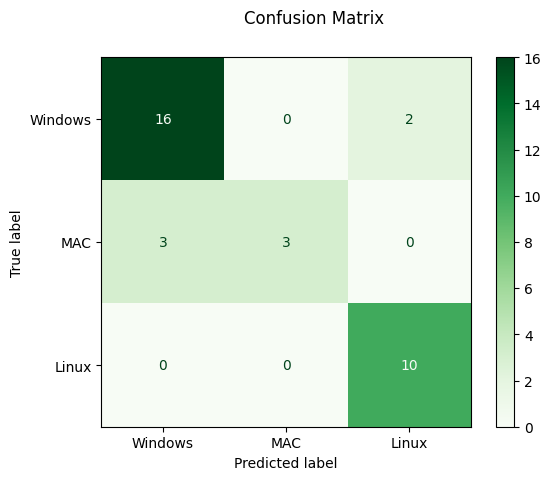

In [47]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
categorias = ["Windows","MAC","Linux"]
fig=ConfusionMatrixDisplay.from_estimator(model, X_validation, Y_validation,display_labels=categorias, cmap="Greens")  
fig.figure_.suptitle("Confusion Matrix")
plt.show()

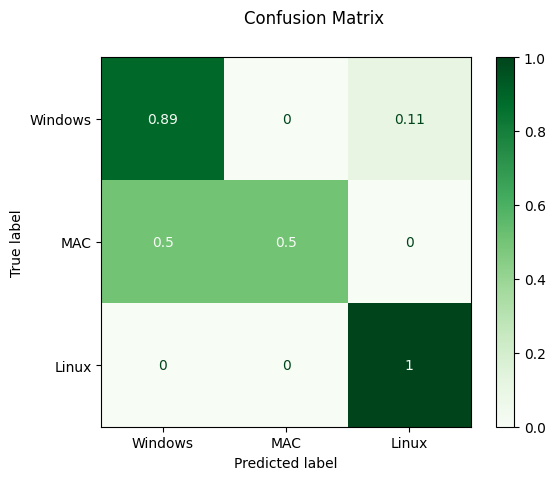

In [48]:
# Matriz de Confusión Normalizada

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
categorias = ["Windows","MAC","Linux"]
fig=ConfusionMatrixDisplay.from_estimator(model, X_validation, Y_validation,display_labels=categorias, cmap="Greens", normalize='true')  
fig.figure_.suptitle("Confusion Matrix")
plt.show()

# Clasificación de nuevos registros

In [49]:
# Se crea un arreglo con valores definidos por el programador, 
# para probar la predicción del modelo. 
X_new = np.array([8,38,5,1]).reshape(1, -1) 
        #pd.DataFrame({'duracion': [8], 'paginas': [38], 'acciones': [5], 'valor': [1]})
pred=model.predict(X_new)
f"La información ingresada corresponde con un usuario de {categorias[pred[0]]}."

'La información ingresada corresponde con un usuario de Linux.'

<div class="alert alert-info", role="success">
    <h1 style="font-size: 2em;">Entrene un modelo para la predicción de la Especie del Pinguino usando solo los datos numéricos presentes en el dataset. </h1>
</div>

**obs.** Retirar también la variable 'year' del dataset

## **[16]** Cargue el dataset y elimine los NaNs si existen

In [50]:
# Carga el dataset palmerpenguins
penguins_df= palmerpenguins.load_penguins()
penguins_df.head()

# Elimina las filas con valor NaNs
penguins_df = penguins_df.dropna()

# Muestra las 5 primeras filas del dataset
display(penguins_df.head())

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007


## **[17]** Genere el dataset solo con las variables numéricas (funcion **.drop()**), separe X & Y para el entrenamiento

In [51]:
from sklearn.preprocessing import LabelEncoder

# Elimina las columnas no numéricas incluyendo a la variable año
x = penguins_df.drop(columns=['species', 'island', 'sex', 'year'])

# Mostrar las 5 primeras filas
print(x.head())

# Codifica la variable objetivo (Y)
y = penguins_df['species']
le = LabelEncoder()
y_encoded = le.fit_transform(y)

   bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
0            39.1           18.7              181.0       3750.0
1            39.5           17.4              186.0       3800.0
2            40.3           18.0              195.0       3250.0
4            36.7           19.3              193.0       3450.0
5            39.3           20.6              190.0       3650.0


## **[18]** Entrene el modelo de predicción mediante Regresión Logística

In [52]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Divide los datos en entrenamiento y prueba (80% entrenamiento, 20% prueba)
x_train, x_test, y_train, y_test = train_test_split(
    x, y_encoded, test_size=0.25, random_state=42
)

# Entrenar el modelo de Regresión Logística
model = LogisticRegression(max_iter=200)
model.fit(x_train, y_train)

c:\Users\Rebeca MG\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=200)

## **[19]** Calcule el *score* de su modelo

In [53]:
# Evalua el modelo con los datos de prueba
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy del modelo en datos de prueba: {accuracy:.2f}")

Accuracy del modelo en datos de prueba: 0.99


## **[20]** Imprima las predicciones de categorías para las instancias usadas para el entrenamiento

In [54]:
# Imprime las predicciones (en etiquetas originales)
predicciones_etiquetas = le.inverse_transform(y_pred)
print("\nPredicciones del modelo sobre los datos de prueba:")
print(predicciones_etiquetas)


Predicciones del modelo sobre los datos de prueba:
['Adelie' 'Chinstrap' 'Adelie' 'Gentoo' 'Adelie' 'Chinstrap' 'Chinstrap'
 'Gentoo' 'Gentoo' 'Gentoo' 'Adelie' 'Adelie' 'Chinstrap' 'Adelie'
 'Chinstrap' 'Adelie' 'Adelie' 'Gentoo' 'Adelie' 'Chinstrap' 'Adelie'
 'Adelie' 'Chinstrap' 'Gentoo' 'Adelie' 'Adelie' 'Gentoo' 'Chinstrap'
 'Gentoo' 'Chinstrap' 'Gentoo' 'Chinstrap' 'Adelie' 'Adelie' 'Chinstrap'
 'Chinstrap' 'Gentoo' 'Gentoo' 'Adelie' 'Adelie' 'Adelie' 'Adelie'
 'Gentoo' 'Gentoo' 'Adelie' 'Adelie' 'Chinstrap' 'Adelie' 'Adelie'
 'Chinstrap' 'Adelie' 'Gentoo' 'Gentoo' 'Adelie' 'Adelie' 'Gentoo'
 'Chinstrap' 'Adelie' 'Gentoo' 'Gentoo' 'Chinstrap' 'Chinstrap'
 'Chinstrap' 'Adelie' 'Adelie' 'Chinstrap' 'Adelie' 'Gentoo' 'Adelie'
 'Chinstrap' 'Adelie' 'Adelie' 'Gentoo' 'Chinstrap' 'Gentoo' 'Gentoo'
 'Adelie' 'Adelie' 'Adelie' 'Gentoo' 'Adelie' 'Adelie' 'Gentoo' 'Adelie']


<div class="alert alert-info", role="success">
    <h1 style="font-size: 2em;">Convierta las variables categóricas Sex e Isla a un formato numérico y entrene un nuevo clasificador para la especie del pinguino </h1>
</div>


## **[21]** Cargue el Dataset y separe las secuencias X & Y para el entrenamiento.

In [55]:
# Carga el dataset palmerpenguins
penguins_df= palmerpenguins.load_penguins()
penguins_df.head()

# Elimina las filas con valor NaNs
penguins_df = penguins_df.dropna()

# Muestra las 5 primeras filas del dataset
display(penguins_df.head())

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007


## **[22]** Aplique el LabelEncoder

In [57]:
# Codifica las variables categóricas: 'sex' e 'island'
le_sex = LabelEncoder()
le_island = LabelEncoder()
penguins_df['sex'] = le_sex.fit_transform(penguins_df['sex'])
penguins_df['island'] = le_island.fit_transform(penguins_df['island'])

# Prepara las variables independientes (X) y dependiente (y)
x = penguins_df.drop(columns=['species', 'year'])  # Incluye variables numéricas + sex, island
y = penguins_df['species']
le_species = LabelEncoder()
y_encoded = le_species.fit_transform(y)

## **[23]** Entrene el modelo de predicción mediante Regresión Logística

In [58]:
# Entranamiento completo del modelo sin división 
model_full = LogisticRegression(max_iter=200)
model_full.fit(x, y_encoded)

c:\Users\Rebeca MG\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=200)

## **[24]** Calcule el *score* de su modelo

In [59]:
score_full = model_full.score(x, y_encoded)
print(f"Score del modelo en todo el dataset: {score_full:.2f}")

Score del modelo en todo el dataset: 1.00


## **[25]** Divida esta secuencia anterior en Train/Test 

In [60]:
# División Train/Test
x_train, x_test, y_train, y_test = train_test_split(
    x, y_encoded, test_size=0.25, random_state=42
)

## **[26]** Entrene el modelo de predicción mediante Regresión Logística

In [61]:
# ENTRENAMIENTO con datos de train/test
model_split = LogisticRegression(max_iter=200)
model_split.fit(x_train, y_train)

c:\Users\Rebeca MG\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=200)

## **[27]** Calcule el *score* de su modelo 

In [62]:
# Evalua el modelo con datos de prueba
score_test = model_split.score(x_test, y_test)
print(f"Score del modelo en datos de prueba: {score_test:.2f}")

Score del modelo en datos de prueba: 0.99


## **[28]** Genere la matriz de confusión de los datos de test 

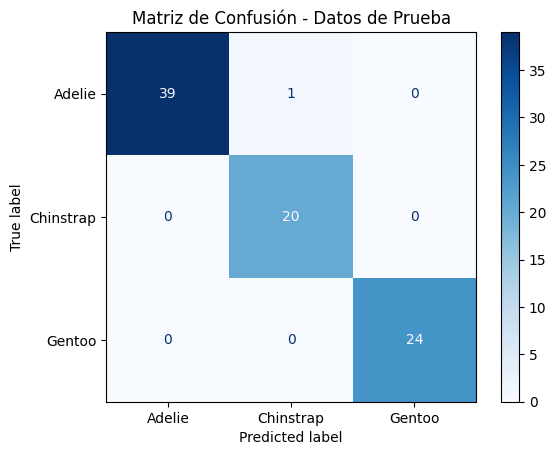

In [63]:
# Muestra la matriz con los datos de prueba
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_species.classes_)
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión - Datos de Prueba')
plt.show()

<div class="alert alert-info", role="success">
    <h1 style="font-size: 2em;">Entrene un modelo de clasificación para el atributo <strong>cut</strong> del dataset Diamonds.</h1>
</div>

## **[29]** Cargue el dataset y elimine los NaNs de ser necesario

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar dataset diamonds
diamonds_df = sns.load_dataset('diamonds')

# Mostrar las 5 primeras filas del dataset
diamonds_df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


## **[30]** Genere el las secuencias X & Y para entrenar el modelo

In [13]:
import seaborn as sns
import pandas as pd


diamonds_df = diamonds_df.dropna()

X = diamonds_df.drop(columns=['price']) 
y = diamonds_df['price']

X = pd.get_dummies(X, columns=['cut', 'color', 'clarity'], drop_first=True)

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)


Forma de X: (53940, 23)
Forma de y: (53940,)


## **[31]** Aplique el LabelEncoder

In [15]:
from sklearn.preprocessing import LabelEncoder

df = diamonds_df.copy()

le = LabelEncoder()

for col in ['cut', 'color', 'clarity']:
    df[col] = le.fit_transform(df[col])

X = df.drop(columns=['price'])
y = df['price']

print(X.head())


   carat  cut  color  clarity  depth  table     x     y     z
0   0.23    2      1        3   61.5   55.0  3.95  3.98  2.43
1   0.21    3      1        2   59.8   61.0  3.89  3.84  2.31
2   0.23    1      1        4   56.9   65.0  4.05  4.07  2.31
3   0.29    3      5        5   62.4   58.0  4.20  4.23  2.63
4   0.31    1      6        3   63.3   58.0  4.34  4.35  2.75


## **[32]** Divida el dataset en conjunto de Train y Test

In [ ]:
from sklearn.model_selection import train_test_split

# Dividir el dataset en 80% entrenamiento y 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Mostrar las formas de los conjuntos
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (43152, 9)
X_test shape: (10788, 9)
y_train shape: (43152,)
y_test shape: (10788,)


## **[33]** Entrene el modelo de predicción mediante Regresión Logística

In [21]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

df = sns.load_dataset('diamonds').dropna()
for col in ['cut', 'color', 'clarity']:
    df[col] = LabelEncoder().fit_transform(df[col])
X = df.drop(columns='price')
y = pd.qcut(df['price'], q=3, labels=[0, 1, 2])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression(max_iter=2000).fit(X_train, y_train)
acc = accuracy_score(y_test, model.predict(X_test))
print(f"Precisión: {acc:.4f}")


Precisión: 0.9215


## **[34]** Calcule el *score* de su modelo

In [22]:
score = model.score(X_test, y_test)
print(f"Score del modelo: {score:.4f}")


Score del modelo: 0.9215


## **[35]** Genere la matriz de confusión de los datos de test 

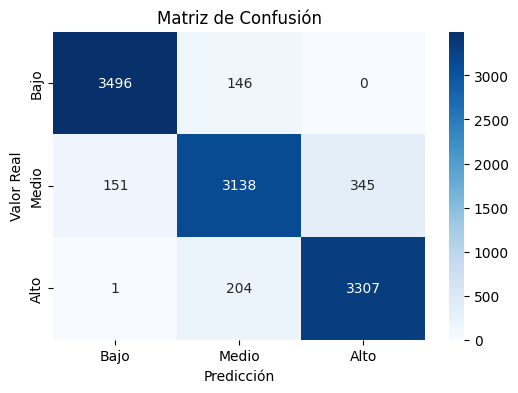

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bajo', 'Medio', 'Alto'],
            yticklabels=['Bajo', 'Medio', 'Alto'])
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión')
plt.show()


<div class="alert alert-info", role="success">
    <h1 style="font-size: 2em;">Utilizando el dataset Cancer de Seno entrene un modelo mediante Regresión Logística que permita diagnosticar la enfermedad basada en datos de entrada
 </h1>
</div>


## **[36]** Cargue el dataset y elimine los NaNs de ser necesario

In [15]:
import pandas as pd
df = pd.read_csv('Breast_cancer_data.csv')


## **[37]** Genere el las secuencias X & Y para entrenar el modelo

In [16]:
df['diagnosis'] = df['diagnosis'].map({'B': 0, 'M': 1})

if 'id' in df.columns:
    df = df.drop('id', axis=1)

X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

print("Tamaño de X:", X.shape)
print("Tamaño de y:", y.shape)


Tamaño de X: (569, 5)
Tamaño de y: (569,)


## **[38]** Divida el dataset en conjunto de Train y Test

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Tamaño del conjunto de entrenamiento:", X_train.shape, y_train.shape)
print("Tamaño del conjunto de prueba:", X_test.shape, y_test.shape)


Tamaño del conjunto de entrenamiento: (120, 4) (120,)
Tamaño del conjunto de prueba: (30, 4) (30,)


## **[39]** Entrene el modelo de predicción mediante Regresión Logística

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


modelo = LogisticRegression(max_iter=10000)
modelo.fit(X_train_scaled, y_train)



,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,10000
,multi_class,'deprecated'


## **[40]** Calcule el *score* de su modelo

In [30]:
score = modelo.score(X_test_scaled, y_test)
print(f"score del modelo (precision en el conjunto de prueba): {score:.4f}")


score del modelo (precision en el conjunto de prueba): 1.0000


## **[41]** Genere la matriz de confusión de los datos de test 

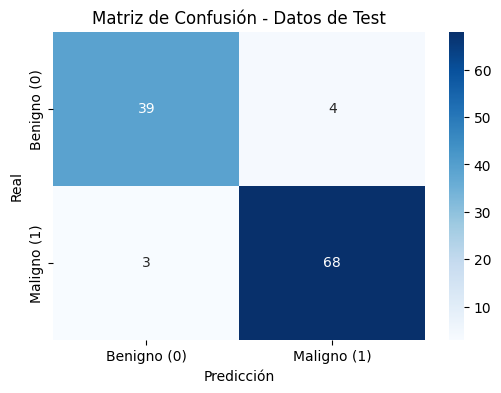

In [ ]:
y_pred = modelo.predict(X_test_scaled)

matriz = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', xticklabels=["Benigno (0)", "Maligno (1)"], yticklabels=["Benigno (0)", "Maligno (1)"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusion - Datos de Test")
plt.show()


<div class="alert alert-success", role="alert">
    <h1 style="font-size: 1.5em;">Parte 3 </h1>
    <h2 style="font-size: 1.5em; "><strong>Random Forest Utilizando SKLearn y Dataset Iris</strong></h2>
</div>


Random Forest es un clasificador basado en el ensamble de varios Árboles de Decisión. Se utiliza tanto para clasificación *RandomForestClassifier* o también en enfoques de regresión *RandomForestRegressor* para variables continuas. El ejemplo utiliza el dataset Iris para clasificar la especie o tipo de flor que se desea identificar basada en 4 variables.

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn import datasets
from sklearn.datasets import load_iris

## Secuencias X & Y para entrenar el modelo

In [21]:
data = load_iris()
X, y = data.data, data.target

## Entenamiento y prueba del modelo

In [22]:
#Definición del Modelo 
clf = RandomForestClassifier(n_jobs=2, random_state=0)
#fit/train -> Se hace el entrenamiendo del modelo
clf.fit(X,y)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [24]:
#Creando un item con los atributos al azar para probar el modelo
X_pred = [2, 2, 4, 2]
#Utilizar el modelo para predecir una especie para nuestra instancia
output = clf.predict([X_pred]) 

## El modelo puede también calcular la probabilidad de cada categoría utilizando la función *predict_proba*

In [25]:
print ('Predicción:', data.target_names[output])
print ('Opciones:', data.target_names)
print ('Probabilidades:', clf.predict_proba([X_pred]))

Predicción: ['virginica']
Opciones: ['setosa' 'versicolor' 'virginica']
Probabilidades: [[0.   0.31 0.69]]


<div class="alert alert-info", role="success">
    <h1 style="font-size: 2em;">Entrene un clasificador de la isla de los pinguinos usando todas las columnas del dataset a excepción del años.</h1>
</div>

## **[42]** Cargue el dataset y elimine los NaNs de ser necesario

In [3]:
import seaborn as sns
import pandas as pd

# Cargar dataset desde seaborn
df = sns.load_dataset("penguins")
print(df.head())



  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  


## **[43]** Genere el las secuencias X & Y para entrenar el modelo

In [4]:
print(df.columns)

df = df.dropna()

y = df['species']

X = df.drop(columns=['species'])

X = pd.get_dummies(X, drop_first=True)


Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')


## **[44]** Aplique el LabelEncoder

In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_encoded = le.fit_transform(y)

print("Clases:", le.classes_)
print("y codificado:", y_encoded[:10])


Clases: ['Adelie' 'Chinstrap' 'Gentoo']
y codificado: [0 0 0 0 0 0 0 0 0 0]


## **[45]** Divida el dataset en conjunto de Train y Test

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

print("Tamaño del conjunto de entrenamiento:", X_train.shape, y_train.shape)
print("Tamaño del conjunto de prueba:", X_test.shape, y_test.shape)


Tamaño del conjunto de entrenamiento: (266, 7) (266,)
Tamaño del conjunto de prueba: (67, 7) (67,)


## **[46]** Entrene el modelo de predicción mediante Random Forest

In [7]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=100, random_state=42)

clf.fit(X_train, y_train)

print("Modelo Random Forest entrenado con exito.")


Modelo Random Forest entrenado con exito.


## **[47]** Calcule el *score* de su modelo

In [8]:
score = clf.score(X_test, y_test)

print(f"Precisipn del modelo Random Forest: {score:.4f}")


Precisipn del modelo Random Forest: 1.0000


## **[48]** Genere la matriz de confusión de los datos de test 

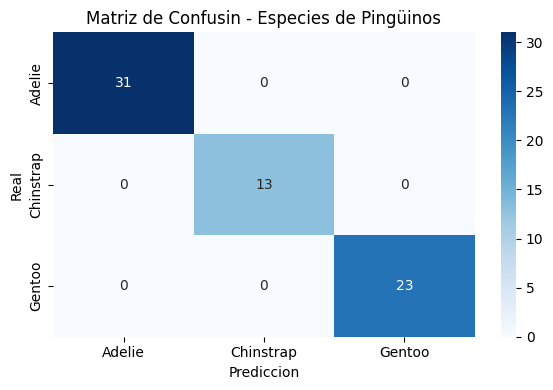

In [9]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Matriz de Confusin - Especies de Pingüinos")
plt.xlabel("Prediccion")
plt.ylabel("Real")
plt.tight_layout()
plt.show()


supported values for cmap are 'Accent', 'Accent_r', 'Blues', 'Blues_r', 'BrBG', 'BrBG_r', 'BuGn', 'BuGn_r', 'BuPu', 'BuPu_r', 'CMRmap', 'CMRmap_r', 'Dark2', 'Dark2_r', 'GnBu', 'GnBu_r', 'Greens', 'Greens_r', 'Greys', 'Greys_r', 'OrRd', 'OrRd_r', 'Oranges', 'Oranges_r', 'PRGn', 'PRGn_r', 'Paired', 'Paired_r', 'Pastel1', 'Pastel1_r', 'Pastel2', 'Pastel2_r', 'PiYG', 'PiYG_r', 'PuBu', 'PuBuGn', 'PuBuGn_r', 'PuBu_r', 'PuOr', 'PuOr_r', 'PuRd', 'PuRd_r', 'Purples', 'Purples_r', 'RdBu', 'RdBu_r', 'RdGy', 'RdGy_r', 'RdPu', 'RdPu_r', 'RdYlBu', 'RdYlBu_r', 'RdYlGn', 'RdYlGn_r', 'Reds', 'Reds_r', 'Set1', 'Set1_r', 'Set2', 'Set2_r', 'Set3', 'Set3_r', 'Spectral', 'Spectral_r', 'Wistia', 'Wistia_r', 'YlGn', 'YlGnBu', 'YlGnBu_r', 'YlGn_r', 'YlOrBr', 'YlOrBr_r', 'YlOrRd', 'YlOrRd_r', 'afmhot', 'afmhot_r', 'autumn', 'autumn_r', 'binary', 'binary_r', 'bone', 'bone_r', 'brg', 'brg_r', 'bwr', 'bwr_r', 'cividis', 'cividis_r', 'cool', 'cool_r', 'coolwarm', 'coolwarm_r', 'copper', 'copper_r', 'crest', 'crest_r', 'cubehelix', 'cubehelix_r', 'flag', 'flag_r', 'flare', 'flare_r', 'gist_earth', 'gist_earth_r', 'gist_gray', 'gist_gray_r', 'gist_heat', 'gist_heat_r', 'gist_ncar', 'gist_ncar_r', 'gist_rainbow', 'gist_rainbow_r', 'gist_stern', 'gist_stern_r', 'gist_yarg', 'gist_yarg_r', 'gnuplot', 'gnuplot2', 'gnuplot2_r', 'gnuplot_r', 'gray', 'gray_r', 'hot', 'hot_r', 'hsv', 'hsv_r', 'icefire', 'icefire_r', 'inferno', 'inferno_r', 'jet', 'jet_r', 'magma', 'magma_r', 'mako', 'mako_r', 'nipy_spectral', 'nipy_spectral_r', 'ocean', 'ocean_r', 'pink', 'pink_r', 'plasma', 'plasma_r', 'prism', 'prism_r', 'rainbow', 'rainbow_r', 'rocket', 'rocket_r', 'seismic', 'seismic_r', 'spring', 'spring_r', 'summer', 'summer_r', 'tab10', 'tab10_r', 'tab20', 'tab20_r', 'tab20b', 'tab20b_r', 'tab20c', 'tab20c_r', 'terrain', 'terrain_r', 'turbo', 'turbo_r', 'twilight', 'twilight_r', 'twilight_shifted', 'twilight_shifted_r', 'viridis', 'viridis_r', 'vlag', 'vlag_r', 'winter', 'winter_r'

<div class="alert alert-info", role="success">
    <h1 style="font-size: 2em;">Utilizando el dataset Cáncer de Seno entrene un modelo mediante Random Forest que permita diagnosticar la enfermedad basada en datos de entrada </h1>
</div>


## **[49]** Cargue el dataset y elimine los NaNs de ser necesario

In [3]:
import pandas as pd
df = pd.read_csv('Breast_cancer_data.csv')


## **[50]** Genere el las secuencias X & Y para entrenar el modelo

In [4]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']


## **[51]** Divida el dataset en conjunto de Train y Test

In [5]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X, y,             
    test_size=0.2,    
    random_state=42    
)
print("Tamaño del conjunto de entrenamiento:", X_train.shape, y_train.shape)
print("Tamaño del conjunto de prueba:", X_test.shape, y_test.shape)


Tamaño del conjunto de entrenamiento: (455, 5) (455,)
Tamaño del conjunto de prueba: (114, 5) (114,)


## **[52]** Entrene el modelo de predicción mediante Random Forest

In [8]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

print("Modelo entrenado con exito :D ")


Modelo entrenado con exito :D 


## **[53]** Calcule el *score* de su modelo

In [11]:
score = rf_model.score(X_test, y_test)

print(f"Score del modelo es de: {score:.4f}")


Score del modelo es de: 0.9474


## **[54]** Genere la matriz de confusión de los datos de test 

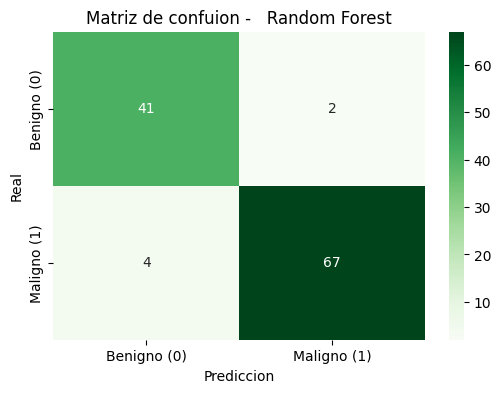

In [23]:
y_pred_rf = rf_model.predict(X_test)

matriz_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 4))
sns.heatmap(matriz_rf, annot=True, fmt='d', cmap='Greens', 
            xticklabels=["Benigno (0)", "Maligno (1)"],
            yticklabels=["Benigno (0)", "Maligno (1)"])
plt.xlabel("Prediccion")
plt.ylabel("Real")
plt.title("Matriz de confuion -   Random Forest")
plt.show()


<div class="alert alert-info", role="success">
    <h1 style="font-size: 2em;"> Utilizando Random Forest Regresor realice la predicción  del precio de los diamantes usando todas las columnas del dataset
 </h1>
</div>


## **[55]** Cargue el dataset y elimine los NaNs de ser necesario

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar el dataset 'diamonds'
diamonds_df = sns.load_dataset('diamonds')

# Mostrar las 5 primeras filas del dataset
print(diamonds_df.head())

   carat      cut color clarity  depth  table  price     x     y     z
0   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43
1   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31
2   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31
3   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63
4   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75


## **[56]** Genere el las secuencias X & Y para entrenar el modelo

In [47]:
def generar_secuencias(datos, ventana=10):
    X, Y = [], []
    for i in range(len(datos) - ventana):
        X.append(datos[i:i+ventana])
        Y.append(datos[i+ventana])
    return np.array(X), np.array(Y)


## **[57]** Aplique el LabelEncoder

In [52]:
from sklearn.preprocessing import LabelEncoder

df_encoded = diamonds_df.copy()


label_cols = ['cut', 'color', 'clarity']
encoder_dict = {}

for col in label_cols:
    encoder = LabelEncoder()
    df_encoded[col] = encoder.fit_transform(df_encoded[col])
    encoder_dict[col] = encoder  

print(df_encoded[label_cols].head())


   cut  color  clarity
0    2      1        3
1    3      1        2
2    1      1        4
3    3      5        5
4    1      6        3


## **[58]** Divida el dataset en conjunto de Train y Test

In [53]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=['price'])  
y = df_encoded['price']                 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)


Train: (43152, 9) (43152,)
Test: (10788, 9) (10788,)


## **[59]** Entrene el modelo de Regresión mediante **RandomForestRegressor**

In [55]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Evaluar
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² del modelo: {r2:.4f}")
print(f"RMSE del modelo: {rmse:.2f}")


R² del modelo: 0.9815
RMSE del modelo: 542.05


## **[60]** Calcule el *score* de su modelo

In [57]:
score = modelo_rf.score(X_test, y_test)

print(f"Score del modelo es: {score:.4f}")


Score del modelo es: 0.9815


## **[61]** Genere un dataframe donde almacene el valor real del conjunto **X** y la predicción para estos valores **X**. 
**Obs.** Utilice para la predicción el conjunto **X** de valores antes de ser dividido en train/test

In [59]:
y_pred_full = modelo_rf.predict(X)

df_resultados = pd.DataFrame({
    'Precio_Real': y,
    'Precio_Predicho': y_pred_full
})

print(df_resultados.head())


   Precio_Real  Precio_Predicho
0          326           405.08
1          326           344.70
2          327           362.45
3          334           371.79
4          335           397.83


## **[62]** Presente el *boxplot* para este dataset

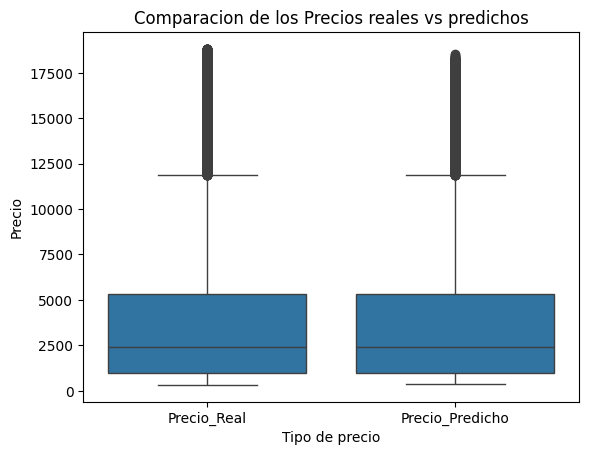

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

df_melted = df_resultados.melt(var_name='Tipo', value_name='Precio')

sns.boxplot(data=df_melted, x='Tipo', y='Precio')
plt.title('Comparacion de los Precios reales vs predichos')
plt.xlabel('Tipo de precio')
plt.ylabel('Precio')
plt.show()


## **[63]** Genere un *lineplot* del dataframe anterior donde compare las predicciones con el valor real. 
## Presente en este gráfico solo las primeras 500 instancias del conjunto. (```iloc[0:500]```) 

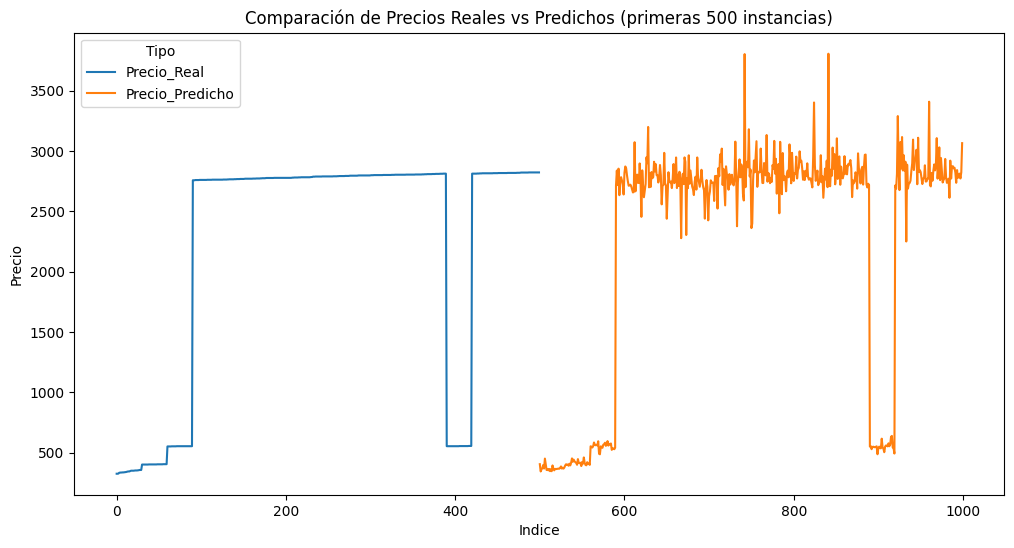

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

df_subset = df_resultados.iloc[0:500]

df_melted_subset = df_subset.melt(var_name='Tipo', value_name='Precio')

plt.figure(figsize=(12,6))
sns.lineplot(data=df_melted_subset, x=df_melted_subset.index, y='Precio', hue='Tipo')
plt.title('Comparación de Precios Reales vs Predichos (primeras 500 instancias)')
plt.xlabel('Indice')
plt.ylabel('Precio')
plt.show()


## **[64]** Conclusiones 

En este laboratorio aplicamos la tecnica del label encoder para poder entrenar distintos modelos de entrenamiento fue una experiencia que nos ayudo bastante a entender como se utilizan distintas herramientas.